In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Plotting style
sns.set_style("dark") 
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

In [2]:
# Organize the excel file in a dataframe
df = pd.read_excel("Concrete_Data.xls")

# Seperate the target variable (Concrete compressive strength) from the rest "predicting" attributes
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '], axis=1)
# Target variable
y= df['Concrete compressive strength(MPa, megapascals) '].values

N, M = X.shape

print(f"Instances: {N}, Attributes: {M} \n") # Instances, Attributes

# Check for missing values across the dataset
print(df.isnull().sum()) 

# Clean the names of the attributes, remove everything after the first '(' in each column name
X.columns = [col.split('(')[0].strip() for col in X.columns]

# Display my dataset (head is only a preview of the first 5 instances)
X.head()

Instances: 1030, Attributes: 8 

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [3]:
# Standard summary statistics
summary = X.describe()

# Calculate the range for every attribute
range_var = X.max() - X.min()
range_var.name = 'range'

# Append the range as a new row using pd.concat
summary1 = pd.concat([summary, range_var.to_frame().T])

# Calculate the IQR for every attribute

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
IQR.name = 'IQR'

# Append the IQR as a new row using pd.concat
summary_total = pd.concat([summary1, IQR.to_frame().T])

# Display the summary
summary_total

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000
range,438.000000,359.400000,200.100000,125.250000,32.200000,344.000000,398.600000,364.000000
IQR,157.625000,142.950000,118.270000,27.100000,10.160000,97.400000,93.050000,49.000000


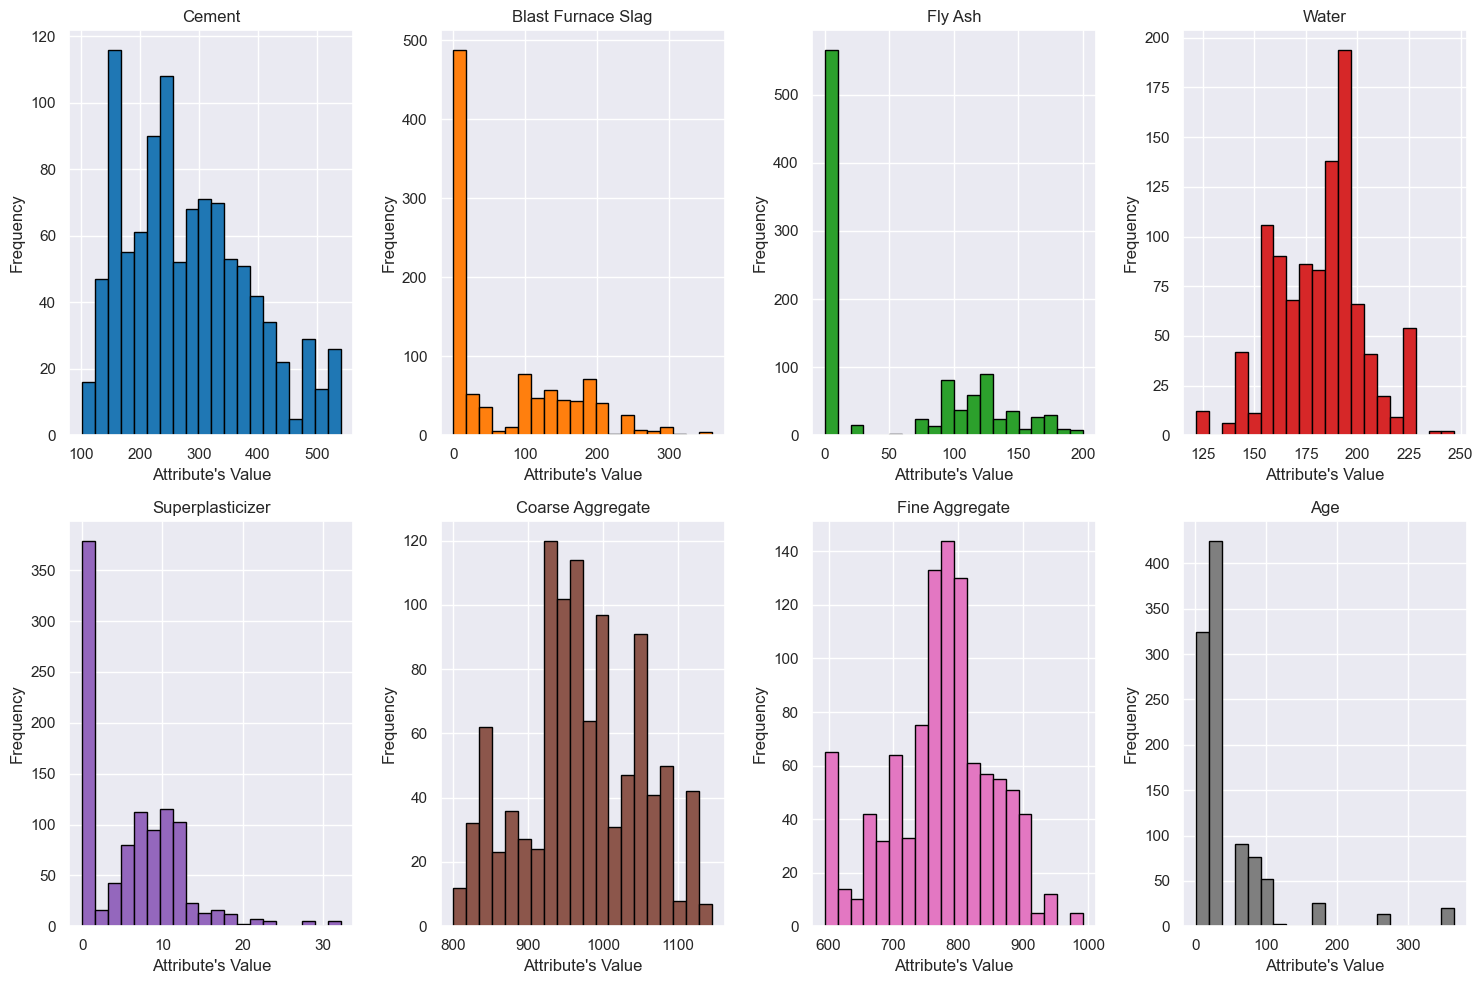

In [4]:
# # # HISTOGRAMS # # #

# Assign each attribute to a specific color
colors = [
    "tab:blue", "tab:orange", "tab:green", "tab:red",
    "tab:purple", "tab:brown", "tab:pink", "tab:gray"
]

fig, ax = plt.subplots(2, 4, figsize=(15, 10))
ax = ax.ravel()

# Take the first 8 columns (all features)
for i in range(8):  
    ax[i].hist(X.iloc[:, i], bins=20, color=colors[i], edgecolor="black")
    ax[i].set_title(X.columns[i])
    ax[i].set_xlabel("Attribute's Value")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

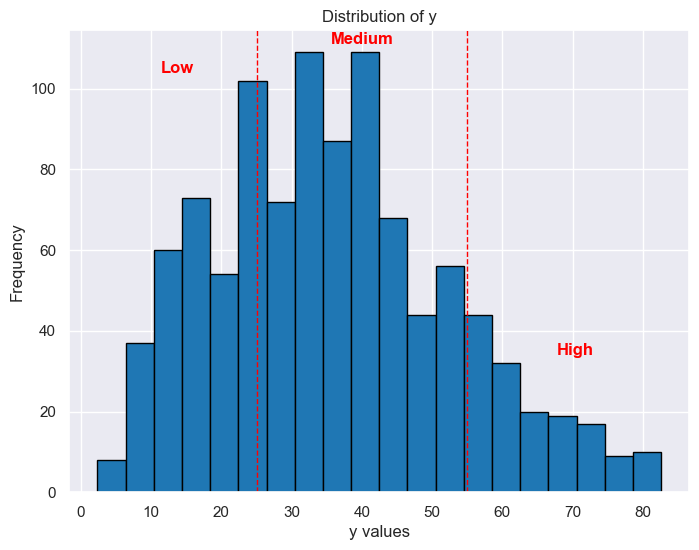

Min: 2.33 MPa
Max: 82.60 MPa
Mean: 35.82 MPa
Low Compressive Strength: 28.6%
Medium Compressive Strength: 57.1%
High Compressive Strength: 14.2%


In [18]:
# for the target variable 
plt.figure(figsize=(8, 6))
counts, bins_edges, patches = plt.hist(y, bins=20, color="tab:blue", edgecolor="black")

plt.title("Distribution of y")
plt.xlabel("y values")
plt.ylabel("Frequency")

categories = [
    ("Low", 2.33, 25.01),
    ("Medium", 25.02, 55.02),
    ("High", 55.03, 85.70)
]

# Labels über den Bereichen platzieren
for label, start, end in categories:
    # x-Position: Mitte des Bereichs
    x_pos = (start + end) / 2
    # y-Position: oberhalb des höchsten Balkens in diesem Bereich
    y_pos = counts[(bins_edges[:-1] >= start) & (bins_edges[:-1] < end)].max() + 2
    plt.text(x_pos, y_pos, label, ha='center', fontsize=12, fontweight='bold', color='red')


for boundary in [25.01, 55.02]:
    plt.axvline(boundary, color='red', linestyle='--', linewidth=1)

plt.show()


print(f"Min: {y.min():.2f} MPa")
print(f"Max: {y.max():.2f} MPa")
print(f"Mean: {y.mean():.2f} MPa")

low_mask = (y >= 2.33) & (y <= 25.01)
medium_mask = (y >= 25.02) & (y <= 55.02)
high_mask = (y >= 55.03) & (y <= 85.70)

low_pct = low_mask.mean() * 100
medium_pct = medium_mask.mean() * 100
high_pct = high_mask.mean() * 100

print(f"Low Compressive Strength: {low_pct:.1f}%")
print(f"Medium Compressive Strength: {medium_pct:.1f}%")
print(f"High Compressive Strength: {high_pct:.1f}%")

In [19]:
print("Test")

Test


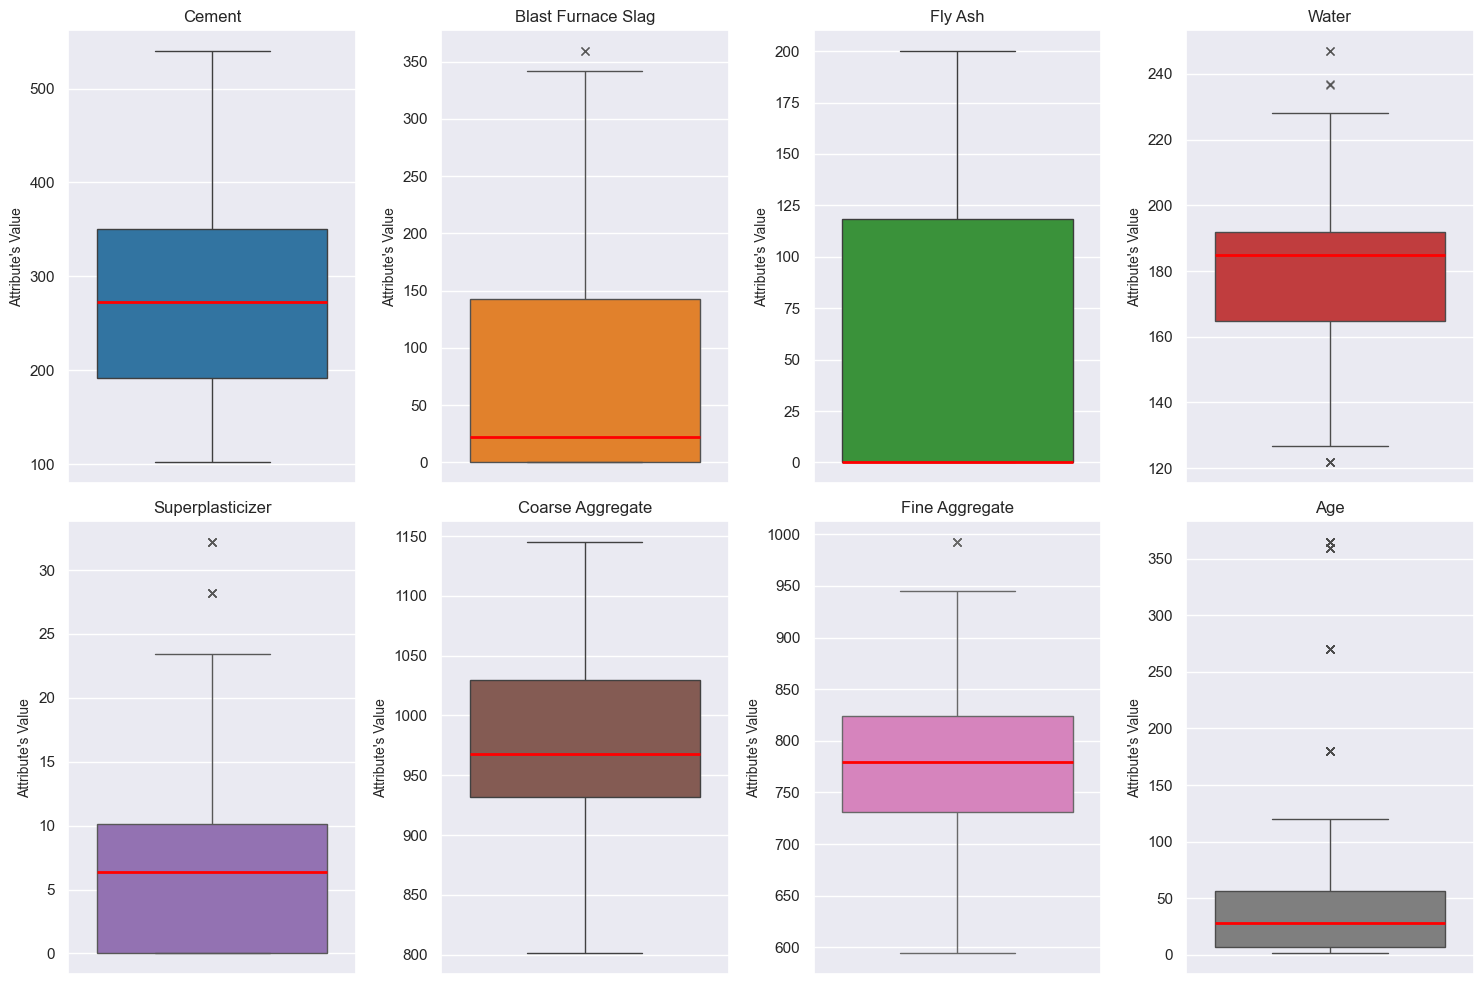

In [6]:
# # # BOXPLOTS # # #

fig, ax = plt.subplots(2, 4, figsize=(15, 10))
ax = ax.ravel()

# Take the first 8 columns/features
for i in range(8):  
    sns.boxplot(
        y=X.iloc[:, i],
        ax=ax[i],
        color=colors[i],
    medianprops=dict(color="red", linewidth=2), # Median line is set to red color
    flierprops=dict(marker="x", color="black", alpha=0.8)  # Outliers  
    )
    ax[i].set_title(X.columns[i], fontsize=12)
    ax[i].set_xlabel("")  
    ax[i].set_ylabel("Attribute's Value", fontsize=10)

plt.tight_layout()
plt.show()

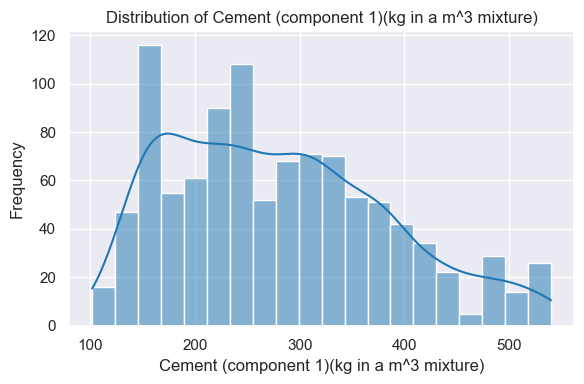

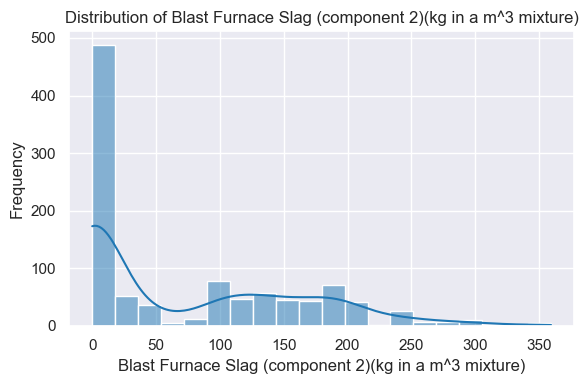

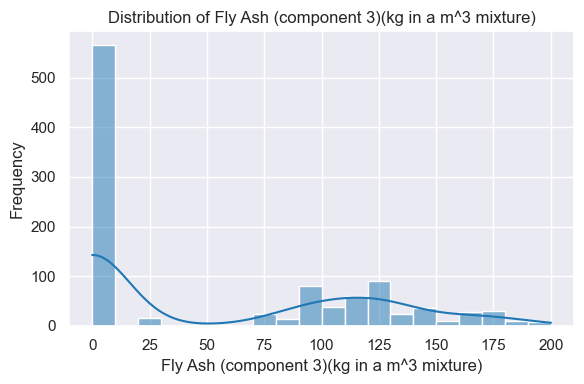

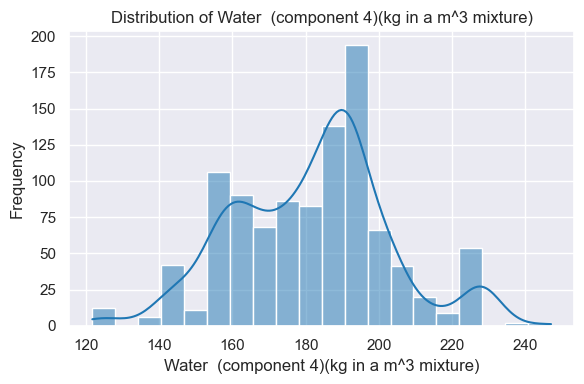

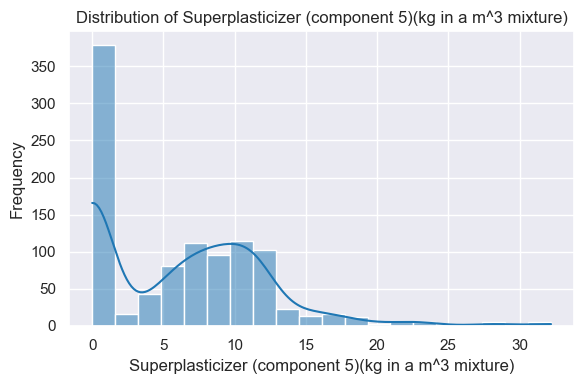

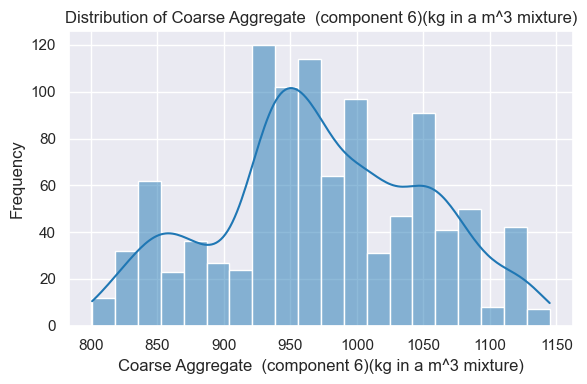

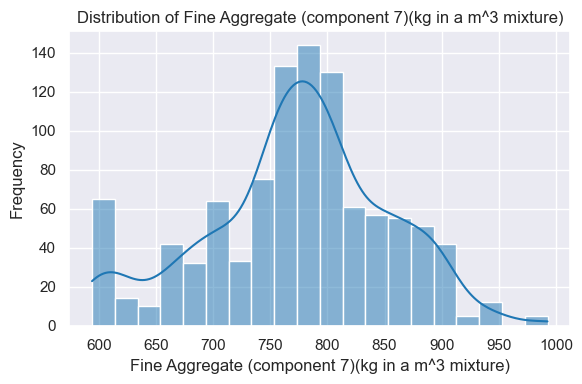

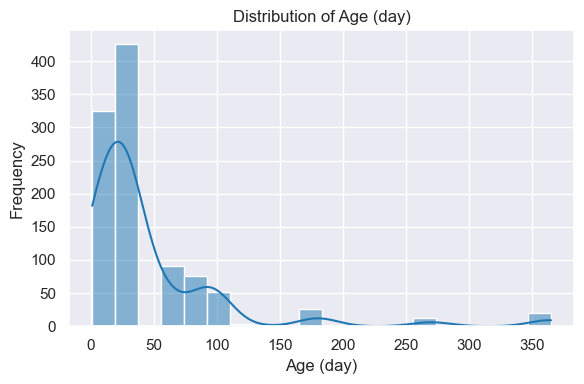

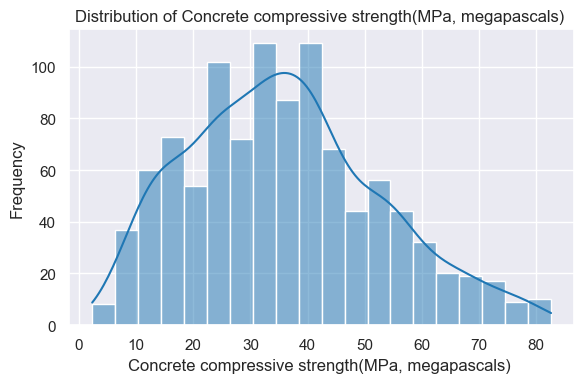

In [7]:
# # # DISTRIBUTION PLOTS # # #

# Distribution of attributes and target variable
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='tab:blue')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [8]:
# # # SCATTER PLOTS # # #

# # Not sure if this part is necessary

# fig, ax = plt.subplots(2, 4, figsize=(15, 12))
# ax = ax.ravel()

# # Take the first 8 columns/features
# for i in range(8):  
#     ax[i].scatter(X.iloc[:, i], y, color=colors[i], alpha=0.6)
#     ax[i].set_xlabel(X.columns[i], fontsize=10)
#     ax[i].set_ylabel("Compressive Strength (MPa)", fontsize=10)
#     ax[i].grid(True)

# plt.tight_layout()
# plt.show()

In [9]:
# # # MATRIX SCATTER PLOT # # #

# # Not sure if this part is necessary

# sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.5, 's':30})
# plt.suptitle("Matrix Scatter Plot", y=1.02)
# plt.show()               

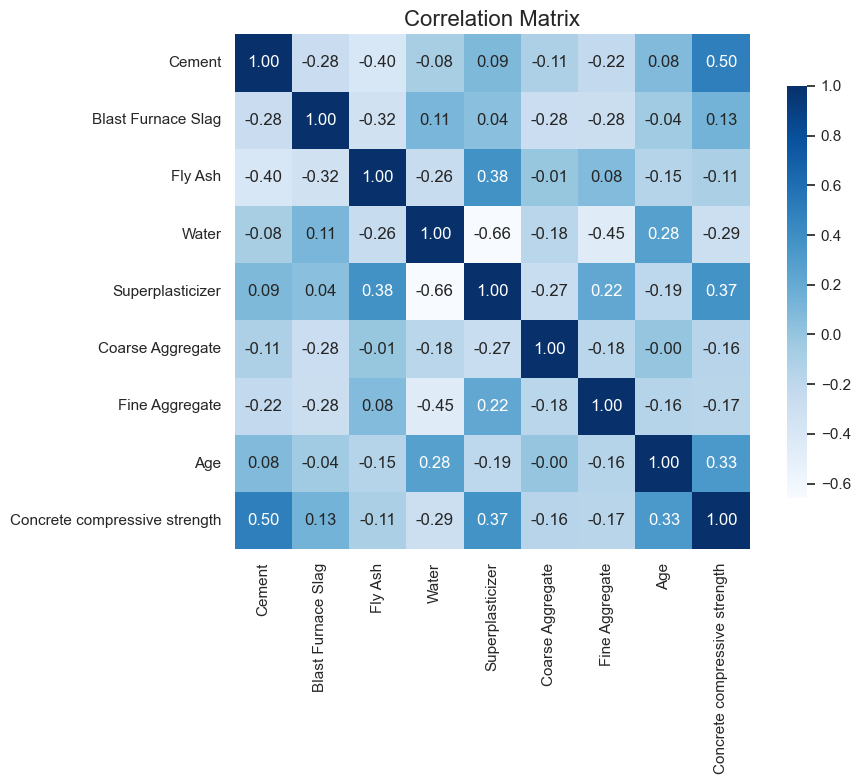

In [10]:
# # # CORRELATION MATRIX # # #

# Clean the names of the dataframe, remove everything after the first '(' in each column name
df.columns = [col.split('(')[0].strip() for col in df.columns]
corr_matrix = df.corr(numeric_only=True)  # Ignore non-numeric columns if there are any
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()

In [11]:
# # Flatten correlation matrix and sort
# correlations = corr_matrix.unstack().sort_values(ascending=False)

# # Remove self-correlations (1s)
# correlations_no_self = correlations[correlations != 1]

# # Select correlations using slicing [1:9:2]
# selected = correlations_no_self.iloc[1:9:2]

# # Drop the second value in this selection (index 1 of 'selected')
# result = selected.drop(selected.index[1])

# print(result)

# Maybe this way is better (?)

# Keep only one triangle from the corr_matrix (k=1 removes diagonal)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Flatten, drop NaNs, sort by absolute value (so strong negative also ranks high)
top_pairs = (upper.stack().sort_values(key=lambda s: s.abs(), ascending=False))

# Print top 10 pairs
print(top_pairs.head(10))  

Water               Superplasticizer                -0.657464
Cement              Concrete compressive strength    0.497833
Water               Fine Aggregate                  -0.450635
Cement              Fly Ash                         -0.397475
Fly Ash             Superplasticizer                 0.377340
Superplasticizer    Concrete compressive strength    0.366102
Age                 Concrete compressive strength    0.328877
Blast Furnace Slag  Fly Ash                         -0.323569
Water               Concrete compressive strength   -0.289613
Blast Furnace Slag  Coarse Aggregate                -0.283998
dtype: float64


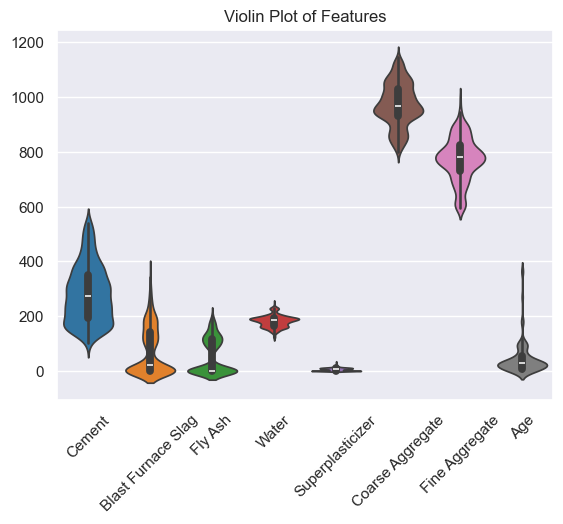

In [12]:
# Are violin plots necessary 

sns.violinplot(data=X, palette=colors)
plt.title("Violin Plot of Features")
plt.xticks(rotation=45)
plt.show()

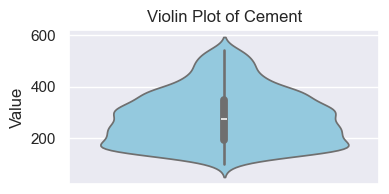

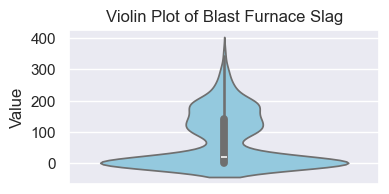

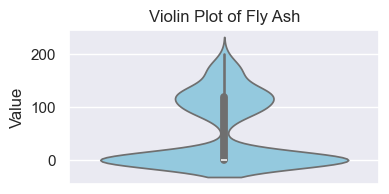

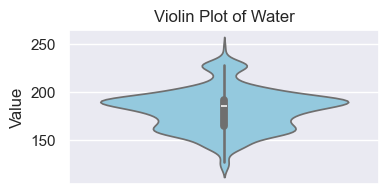

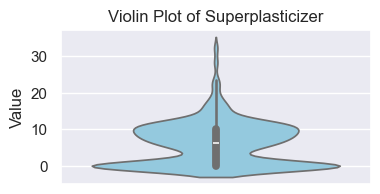

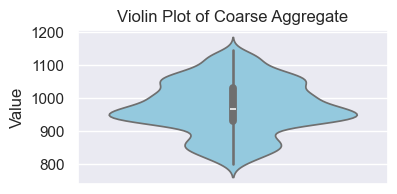

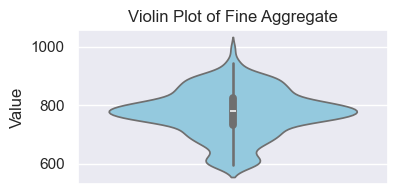

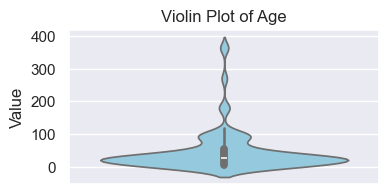

In [13]:
# Are violin plots necessary (?)

for col in X.columns:
    plt.figure(figsize=(4,2))
    sns.violinplot(y=X[col], color='skyblue')  
    plt.title(f"Violin Plot of {col}")
    plt.ylabel('Value')
    plt.show()
    plt.close()

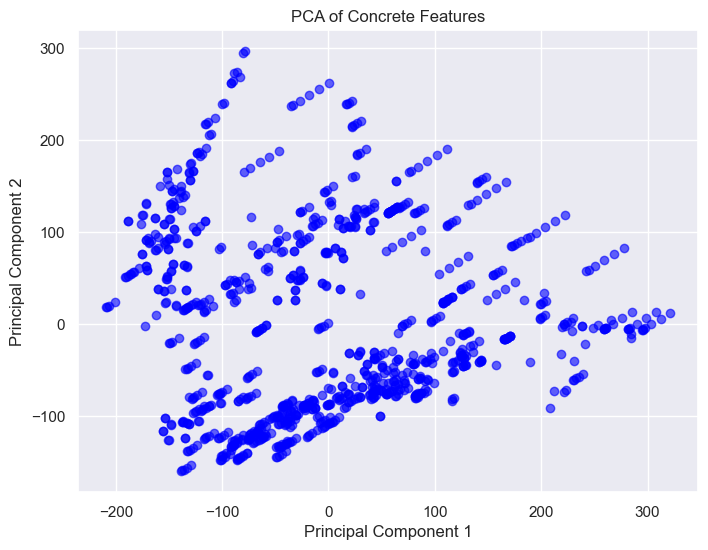

In [14]:
# # # PCA (ATTEMPT 1) # # #

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Concrete Features')
plt.show()

In [15]:
# # # PCA (ATTEMPT 2) # # #

# Save the attributes' names
attributes = X.columns.tolist()

# Standardize features
scaler = StandardScaler()
X_standard = scaler.fit_transform(X) 
pca = PCA(n_components=X.shape[1], random_state=0)
pca_comp = pca.fit_transform(X_standard)  

# Loadings: how each original feature contributes to each PC
loadings = pd.DataFrame(pca.components_, columns=attributes, index=[f"PC{i+1}" for i in range(pca.n_components_)] ).T  # Transpose to show rows as attributes
print("PCA loadings (feature contributions to each PC):")
print(loadings.round(3))


PCA loadings (feature contributions to each PC):
                      PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
Cement              0.098 -0.112  0.814  0.054 -0.148 -0.203 -0.222  0.446
Blast Furnace Slag  0.177  0.686 -0.173  0.363  0.021  0.305 -0.228  0.437
Fly Ash            -0.395 -0.144 -0.408 -0.227 -0.550 -0.183 -0.352  0.382
Water               0.547  0.053 -0.213 -0.296 -0.070 -0.366  0.524  0.389
Superplasticizer   -0.506  0.284  0.234  0.037 -0.354  0.193  0.665  0.052
Coarse Aggregate    0.038 -0.630 -0.173  0.546  0.033  0.315  0.227  0.349
Fine Aggregate     -0.402 -0.020 -0.005 -0.386  0.701  0.092  0.039  0.433
Age                 0.292 -0.126  0.101 -0.528 -0.228  0.744 -0.069  0.013


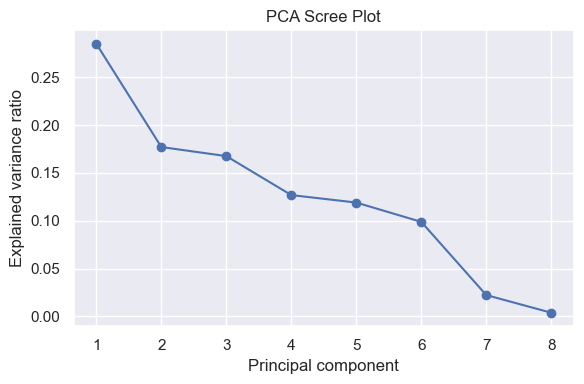

Explained variance ratio per PC: [0.285 0.177 0.168 0.127 0.119 0.099 0.022 0.004]


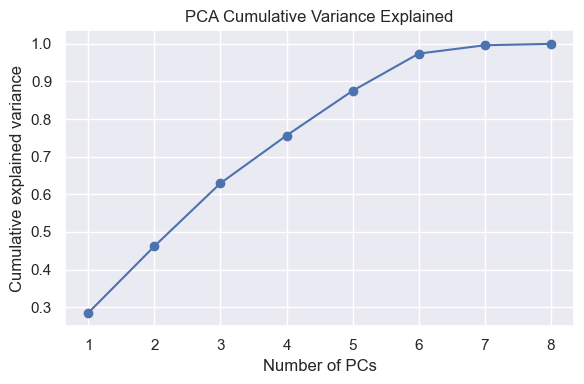

Cumulative explained variance: [0.285 0.462 0.63  0.756 0.875 0.974 0.996 1.   ]


In [16]:
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(evr)+1), evr, marker='o')
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Explained variance ratio per PC:", np.round(evr, 3))

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_evr)+1), cum_evr, marker='o')
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Variance Explained")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Cumulative explained variance:", np.round(cum_evr, 3))

In [17]:
plt.figure(figsize=(6,5))
sc = plt.scatter(Z[:,0], Z[:,1], c=y, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2) — colored by Strength")
cbar = plt.colorbar(sc)
cbar.set_label(target)
plt.tight_layout()
plt.show()
plt.figure(figsize=(7,6))

sc = plt.scatter(Z[:,0], Z[:,1], c=y, alpha=0.5)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA Biplot (PC1–PC2)")

NameError: name 'Z' is not defined

<Figure size 600x500 with 0 Axes>

C:\Users\chris\AppData\Local\Temp\ipykernel_20304\3433490884.py:8: UserWarning: Adding colorbar to a different Figure <Figure size 700x600 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(sc); cbar.set_label(target)


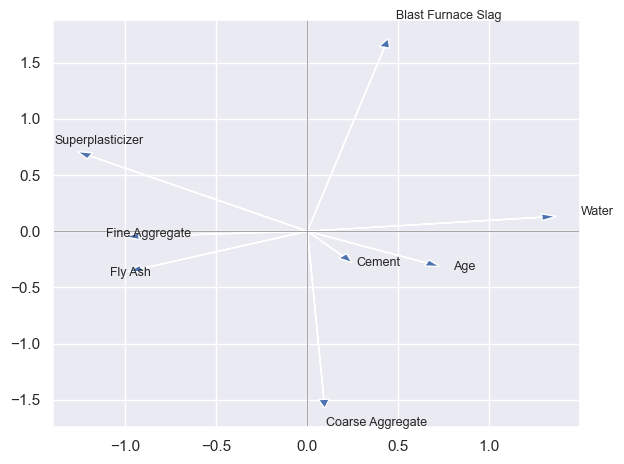

In [ ]:
arrow_scale = 2.5 # Scale arrows
for i, feat in enumerate(feature_names):
    plt.arrow(0, 0, pca.components_[0, i]*arrow_scale, pca.components_[1, i]*arrow_scale,
              head_width=0.06, head_length=0.08, length_includes_head=True)
    plt.text(pca.components_[0, i]*arrow_scale*1.1,
             pca.components_[1, i]*arrow_scale*1.1, feat, fontsize=9)

cbar = plt.colorbar(sc); cbar.set_label(target)
plt.axhline(0, color='grey', lw=0.5); plt.axvline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()